## 1. Load processed data

In this notebook, we analyze quarterly CPI inflation in Turkey and the Global World Uncertainty Index (GDP-weighted).
All datasets are already cleaned and aligned to a common quarterly period.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

processed_dir = Path("../data/processed")

df_cpi = pd.read_csv(processed_dir / "cpi_nfne_yoy_quarterly_mean_turkey.csv")
df_wui = pd.read_csv(processed_dir / "wui_global_gdp_quarterly.csv")

df_cpi["date"] = pd.to_datetime(df_cpi["date"])
df_wui["date"] = pd.to_datetime(df_wui["date"])

df_cpi.head(), df_wui.tail()

(        date  cpi_yoy_nfne
 0 1994-01-01     74.282243
 1 1994-04-01    107.848267
 2 1994-07-01    110.900267
 3 1994-10-01    109.544433
 4 1995-01-01    111.855033,
           date  wui_global_gdp
 121 2024-04-01        15096.69
 122 2024-07-01        19263.25
 123 2024-10-01        26370.25
 124 2025-01-01        48145.70
 125 2025-04-01        80038.14)

## 2. CPI inflation in Turkey (quarterly)

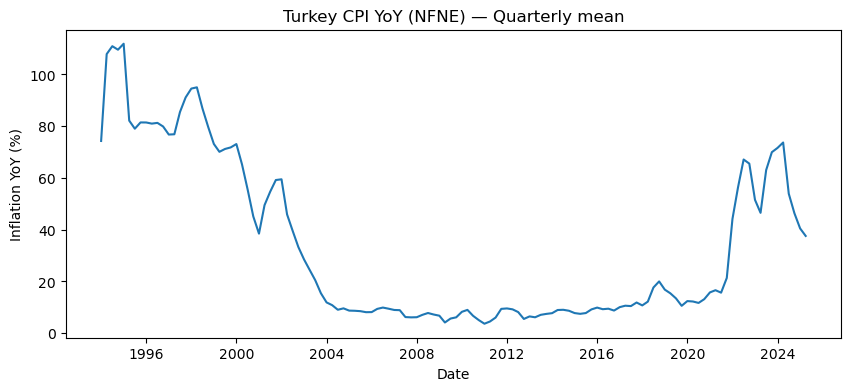

In [3]:
plt.figure(figsize=(10,4))
plt.plot(df_cpi["date"], df_cpi["cpi_yoy_nfne"])
plt.title("Turkey CPI YoY (NFNE) — Quarterly mean")
plt.xlabel("Date")
plt.ylabel("Inflation YoY (%)")
plt.show()

## 3. Global uncertainty dynamics

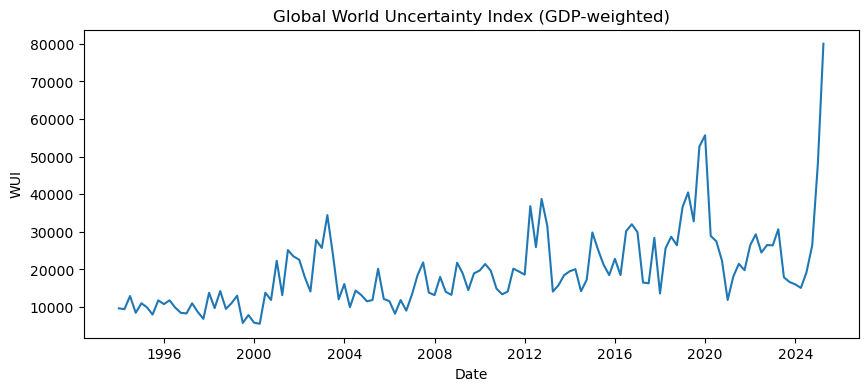

In [4]:
plt.figure(figsize=(10,4))
plt.plot(df_wui["date"], df_wui["wui_global_gdp"])
plt.title("Global World Uncertainty Index (GDP-weighted)")
plt.xlabel("Date")
plt.ylabel("WUI")
plt.show()

## 4. Rolling averages

To better understand medium-term dynamics, we compute rolling means for CPI inflation and WUI. 
This helps identify regime shifts and persistent trends.

In [5]:
df_cpi["cpi_rolling_12q"] = (
    df_cpi
    .set_index("date")["cpi_yoy_nfne"]
    .rolling(window=12)
    .mean()
    .reset_index(drop=True)
)

In [6]:
df_wui["wui_rolling_12q"] = (
    df_wui
    .set_index("date")["wui_global_gdp"]
    .rolling(window=12)
    .mean()
    .reset_index(drop=True)
)

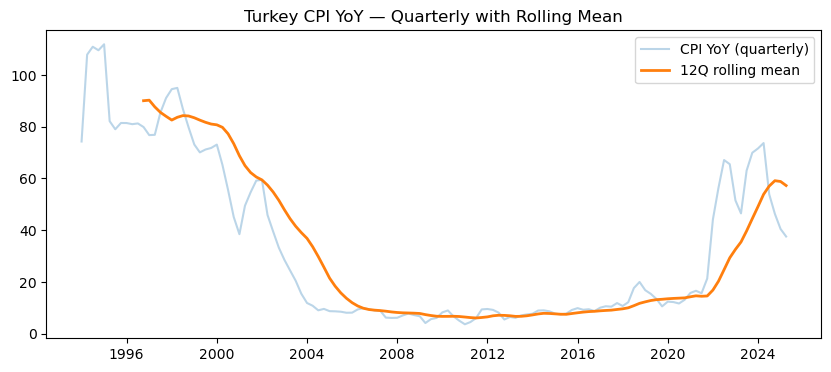

In [7]:
plt.figure(figsize=(10,4))
plt.plot(df_cpi["date"], df_cpi["cpi_yoy_nfne"], alpha=0.3, label="CPI YoY (quarterly)")
plt.plot(df_cpi["date"], df_cpi["cpi_rolling_12q"], linewidth=2, label="12Q rolling mean")
plt.title("Turkey CPI YoY — Quarterly with Rolling Mean")
plt.legend()
plt.show()

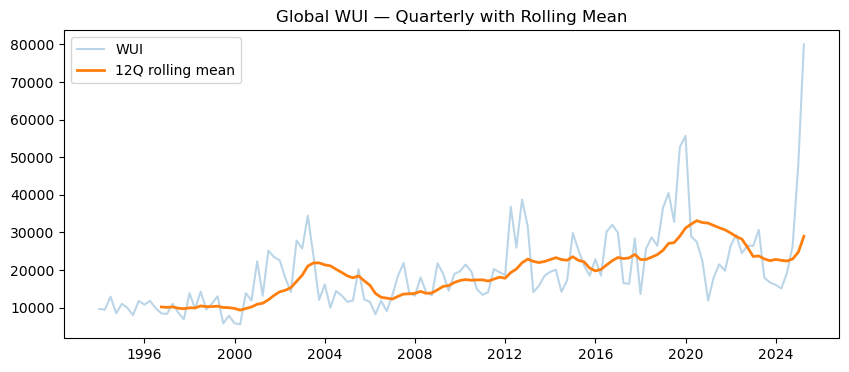

In [8]:
plt.figure(figsize=(10,4))
plt.plot(df_wui["date"], df_wui["wui_global_gdp"], alpha=0.3, label="WUI")
plt.plot(df_wui["date"], df_wui["wui_rolling_12q"], linewidth=2, label="12Q rolling mean")
plt.title("Global WUI — Quarterly with Rolling Mean")
plt.legend()
plt.show()

Rolling averages smooth short-term fluctuations and highlight persistent trends.
While headline CPI inflation shows sharp quarterly spikes, the rolling mean indicates a sustained high-inflation regime since 2021.
Similarly, the smoothed WUI series suggests that recent uncertainty reflects a prolonged period of elevated global risk rather than a one-off shock.

## 5. Comparing inflation and uncertainty dynamics

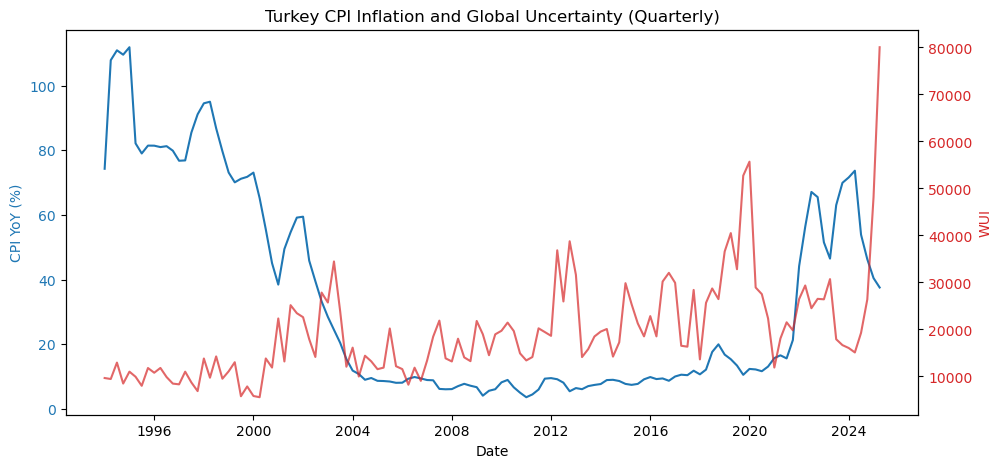

In [9]:
fig, ax1 = plt.subplots(figsize=(11,5))

# CPI on left axis
ax1.plot(
    df_cpi["date"],
    df_cpi["cpi_yoy_nfne"],
    color="tab:blue",
    label="CPI YoY (Turkey)"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("CPI YoY (%)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# WUI on right axis
ax2 = ax1.twinx()
ax2.plot(
    df_wui["date"],
    df_wui["wui_global_gdp"],
    color="tab:red",
    label="Global WUI (GDP-weighted)",
    alpha=0.7
)
ax2.set_ylabel("WUI", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Turkey CPI Inflation and Global Uncertainty (Quarterly)")
plt.show()

### Visual comparison: CPI inflation and global uncertainty

The figure compares Turkey’s quarterly CPI inflation (YoY, NFNE) with the global GDP-weighted World Uncertainty Index using a dual-axis plot.

Several observations emerge from this comparison. First, prior to 2020, inflation dynamics in Turkey appear largely disconnected from fluctuations in global uncertainty. Periods of high inflation in the 1990s and early 2000s coincide with relatively moderate levels of global uncertainty, suggesting that domestic factors dominated inflation dynamics during this time.

Second, the post-2020 period shows a different pattern. Following the COVID-19 shock, global uncertainty rises sharply, while inflation accelerates with a delay rather than immediately. This temporal sequence is consistent with an “aftershock”-type adjustment, where inflationary pressures materialize after a period of heightened uncertainty rather than contemporaneously.

Overall, the visual evidence suggests that the relationship between global uncertainty and inflation in Turkey is not stable over time and may vary across different economic regimes. Importantly, this comparison is purely descriptive and does not imply a causal relationship.


## 6. Rolling comparison: inflation and uncertainty regimes

To focus on medium-term dynamics rather than short-term fluctuations, we compare rolling averages of CPI inflation and the World Uncertainty Index.

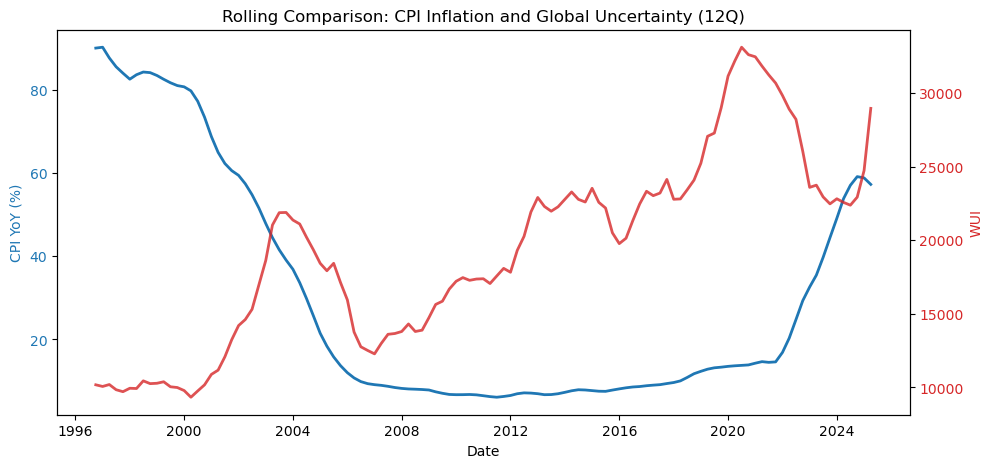

In [10]:
fig, ax1 = plt.subplots(figsize=(11,5))

# CPI rolling mean (left axis)
ax1.plot(
    df_cpi["date"],
    df_cpi["cpi_rolling_12q"],
    color="tab:blue",
    linewidth=2,
    label="CPI YoY (12Q rolling mean)"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("CPI YoY (%)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# WUI rolling mean (right axis)
ax2 = ax1.twinx()
ax2.plot(
    df_wui["date"],
    df_wui["wui_rolling_12q"],
    color="tab:red",
    linewidth=2,
    alpha=0.8,
    label="Global WUI (12Q rolling mean)"
)
ax2.set_ylabel("WUI", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Rolling Comparison: CPI Inflation and Global Uncertainty (12Q)")
plt.show()

### Rolling comparison: CPI inflation and global uncertainty

The rolling comparison highlights medium-term dynamics rather than short-term fluctuations. Before 2020, inflation in Turkey and global uncertainty appear largely disconnected, suggesting that inflation dynamics were mainly driven by
domestic factors.

After 2020, a different pattern emerges. Global uncertainty rises first, while inflation increases with a delay and remains elevated over time. This sequence is consistent with an aftershock-type adjustment, where inflationary pressures materialize after a period of heightened uncertainty rather than immediately.

Overall, the relationship between uncertainty and inflation appears to be regime-dependent and is not stable across the entire sample.

## 7. Lag intuition (EDA)

In [11]:
df = pd.merge(df_cpi, df_wui, on="date", how="inner")
df.shape, df.head()

((126, 5),
         date  cpi_yoy_nfne  cpi_rolling_12q  wui_global_gdp  wui_rolling_12q
 0 1994-01-01     74.282243              NaN        9655.853              NaN
 1 1994-04-01    107.848267              NaN        9446.236              NaN
 2 1994-07-01    110.900267              NaN       12937.130              NaN
 3 1994-10-01    109.544433              NaN        8478.318              NaN
 4 1995-01-01    111.855033              NaN       11010.070              NaN)

In [12]:
df["wui_lag_1"] = df["wui_global_gdp"].shift(1)
df["wui_lag_2"] = df["wui_global_gdp"].shift(2)
df["wui_lag_4"] = df["wui_global_gdp"].shift(4)

df[["date", "wui_global_gdp", "wui_lag_1", "wui_lag_2", "wui_lag_4"]].head(8)

,date,wui_global_gdp,wui_lag_1,wui_lag_2,wui_lag_4
0,1994-01-01,9655.853,NaN,NaN,NaN
1,1994-04-01,9446.236,9655.853,NaN,NaN
2,1994-07-01,12937.130,9446.236,9655.853,NaN
3,1994-10-01,8478.318,12937.130,9446.236,NaN
4,1995-01-01,11010.070,8478.318,12937.130,9655.853
5,1995-04-01,9926.974,11010.070,8478.318,9446.236
6,1995-07-01,8000.667,9926.974,11010.070,12937.130
7,1995-10-01,11781.520,8000.667,9926.974,8478.318


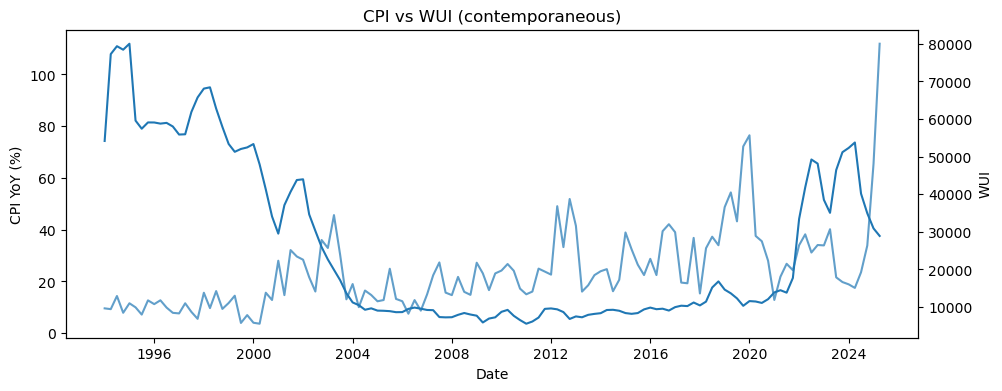

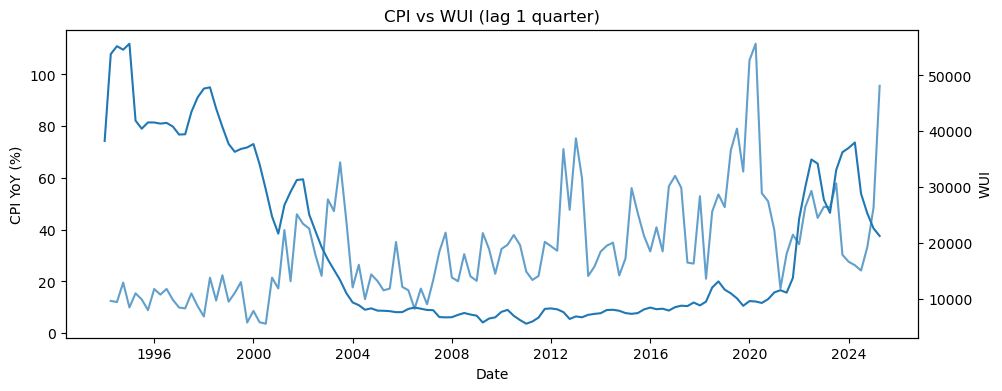

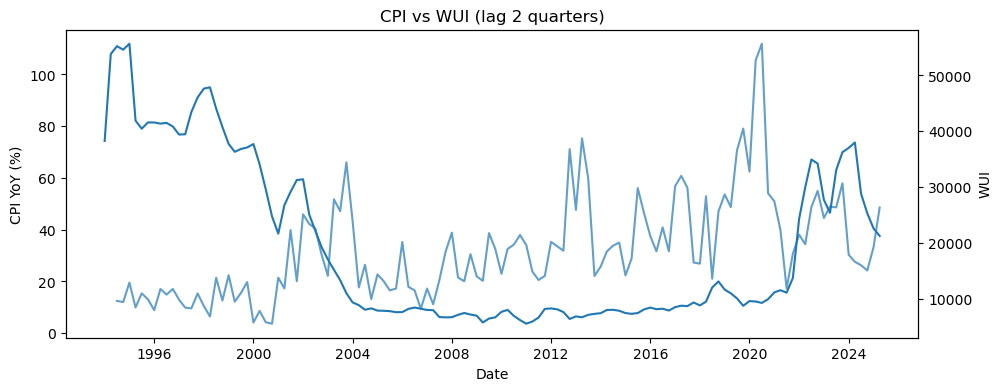

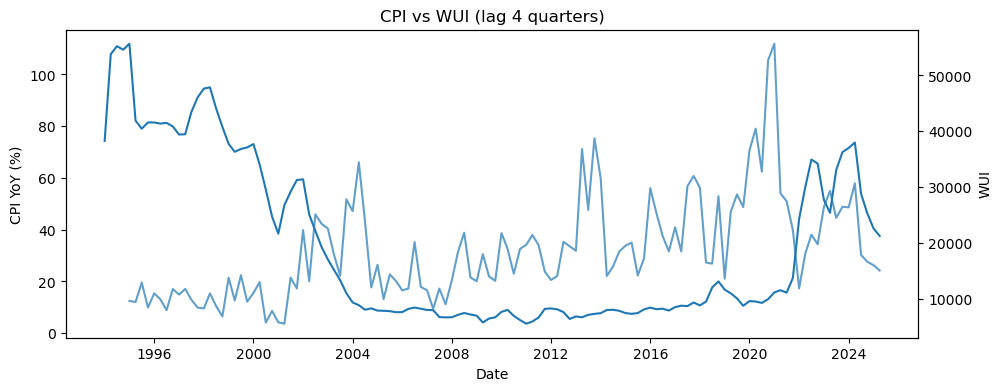

In [13]:
def plot_cpi_vs_wui(x_col, title):
    fig, ax1 = plt.subplots(figsize=(11,4))
    
    ax1.plot(df["date"], df["cpi_yoy_nfne"], label="CPI YoY (Turkey)")
    ax1.set_ylabel("CPI YoY (%)")
    ax1.set_xlabel("Date")
    
    ax2 = ax1.twinx()
    ax2.plot(df["date"], df[x_col], alpha=0.7, label=x_col)
    ax2.set_ylabel("WUI")
    
    plt.title(title)
    plt.show()

plot_cpi_vs_wui("wui_global_gdp", "CPI vs WUI (contemporaneous)")
plot_cpi_vs_wui("wui_lag_1", "CPI vs WUI (lag 1 quarter)")
plot_cpi_vs_wui("wui_lag_2", "CPI vs WUI (lag 2 quarters)")
plot_cpi_vs_wui("wui_lag_4", "CPI vs WUI (lag 4 quarters)")

The visual comparison indicates that inflation reacts to global uncertainty with a delay. The one-year lag provides the clearest alignment, especially in the post-2020 period.

## 8. Shock periods

We define major global shock periods and create dummy variables to examine whether inflation dynamics differ before and after systemic economic shocks.

In [16]:
df["shock_gfc"] = (
    (df["date"] >= "2008-07-01") & (df["date"] <= "2009-12-31")
).astype(int)

df["shock_covid"] = (df["date"] >= "2020-01-01").astype(int)

df[["date", "shock_gfc", "shock_covid"]].iloc[50:70]

,date,shock_gfc,shock_covid
50,2006-07-01,0,0
51,2006-10-01,0,0
52,2007-01-01,0,0
53,2007-04-01,0,0
54,2007-07-01,0,0
55,2007-10-01,0,0
56,2008-01-01,0,0
57,2008-04-01,0,0
58,2008-07-01,1,0
59,2008-10-01,1,0


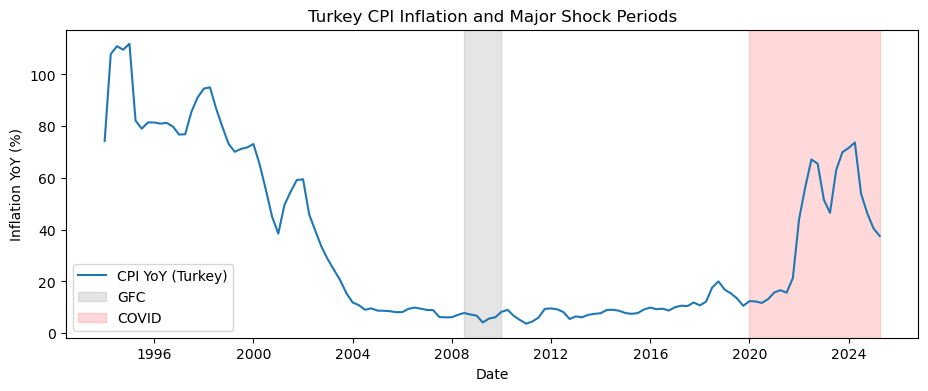

In [17]:
fig, ax = plt.subplots(figsize=(11,4))

ax.plot(df["date"], df["cpi_yoy_nfne"], label="CPI YoY (Turkey)")

ax.axvspan("2008-07-01", "2009-12-31", color="gray", alpha=0.2, label="GFC")
ax.axvspan("2020-01-01", df["date"].max(), color="red", alpha=0.15, label="COVID")

ax.set_title("Turkey CPI Inflation and Major Shock Periods")
ax.set_xlabel("Date")
ax.set_ylabel("Inflation YoY (%)")
ax.legend()

plt.show()

In [18]:
pre_covid = df[df["date"] < "2020-01-01"]["cpi_yoy_nfne"].mean()
post_covid = df[df["date"] >= "2020-01-01"]["cpi_yoy_nfne"].mean()

pre_covid, post_covid

(np.float64(32.02763655128205), np.float64(41.212682121212126))

In [20]:
pre_covid_roll = df[df["date"] < "2020-01-01"]["cpi_rolling_12q"].mean()
post_covid_roll = df[df["date"] >= "2020-01-01"]["cpi_rolling_12q"].mean()

pre_covid_roll, post_covid_roll


(np.float64(29.368024094982083), np.float64(31.438785742424237))

The shock-based analysis highlights a clear change in inflation dynamics after the COVID-19 period. Both headline inflation and its rolling average are substantially higher in the post-2020 period, indicating a shift toward a
high-inflation regime rather than a temporary shock.